<a href="https://colab.research.google.com/github/Abeldb11/LLM_opt/blob/main/Post_training_quantization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers datasets accelerate evaluate scikit-learn
!pip install -q -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 20.8 MB/s eta 0:00:00


In [11]:
import os, time, copy, math, json, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    GPT2LMHeadModel,
    GPT2ForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)
import datasets

datasets.config.TORCHVISION_AVAILABLE = False

from transformers.pytorch_utils import Conv1D
from datasets import load_dataset

import bitsandbytes as bnb

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
assert DEVICE.type == "cuda", "bitsandbytes 8-bit quantization requires a CUDA GPU. Enable a GPU runtime."

Using device: cuda


In [3]:
MODEL_NAME = "gpt2"          # 124M student / baseline
TEACHER_NAME = "gpt2-medium"  # 355M teacher, used only during KD, then freed

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def free(*models):
    """Delete model objects and clear the CUDA cache -- keeps peak memory down
    across this notebook's many sequential model builds."""
    for m in models:
        del m
    gc.collect()
    torch.cuda.empty_cache()

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [7]:
wikitext = load_dataset("salesforce/wikitext", "wikitext-2-raw-v1")
wikitext_test = wikitext["test"].filter(lambda x: len(x["text"].strip()) > 0)
wikitext_train = wikitext["train"].filter(lambda x: len(x["text"].strip()) > 0)

from datasets import load_dataset

sst2 = load_dataset("nyu-mll/glue", "sst2")

train_subset = sst2["train"].shuffle(seed=SEED).select(range(4000))
val_subset = sst2["validation"]


def tokenize_sst2(examples):
    return tokenizer(examples["sentence"], truncation=True, max_length=128)


train_tok = train_subset.map(tokenize_sst2, batched=True)
val_tok = val_subset.map(tokenize_sst2, batched=True)
train_tok = train_tok.rename_column("label", "labels")
val_tok = val_tok.rename_column("label", "labels")
train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def prepare_lm_dataset(dataset, tokenizer, block_size=512):
    def tokenize_fn(examples):
        return tokenizer(examples["text"],
                         return_attention_mask=False,)

    tokenized = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

    def group_texts(examples):
        concatenated = sum(examples["input_ids"], [])
        total_len = (len(concatenated) // block_size) * block_size
        result = {"input_ids": [concatenated[i:i + block_size] for i in range(0, total_len, block_size)]}
        result["labels"] = result["input_ids"].copy()
        return result

    lm_dataset = tokenized.map(group_texts, batched=True)
    lm_dataset.set_format(type="torch", columns=["input_ids", "labels"])
    return lm_dataset


lm_train_dataset = prepare_lm_dataset(wikitext_train, tokenizer, block_size=512)

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/23767 [00:00<?, ? examples/s]

Map:   0%|          | 0/23767 [00:00<?, ? examples/s]

In [8]:
@torch.no_grad()
def compute_perplexity(model, tokenizer, text_dataset, stride=512, max_length=1024):
    model.eval()
    text = "\n\n".join(text_dataset["text"])
    encodings = tokenizer(text, return_tensors="pt")
    input_ids = encodings.input_ids

    seq_len = input_ids.size(1)
    nlls = []
    prev_end = 0
    for begin in range(0, seq_len, stride):
        end = min(begin + max_length, seq_len)
        trg_len = end - prev_end
        ids = input_ids[:, begin:end].to(DEVICE)
        target_ids = ids.clone()
        target_ids[:, :-trg_len] = -100

        outputs = model(ids, labels=target_ids)
        nlls.append(outputs.loss * trg_len)

        prev_end = end
        if end == seq_len:
            break

    ppl = torch.exp(torch.stack(nlls).sum() / prev_end)
    return ppl.item()


def measure_memory(model, tokenizer, seq_len=128, batch_size=8):
    model.eval()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    dummy = torch.randint(0, tokenizer.vocab_size, (batch_size, seq_len)).to(DEVICE)
    with torch.no_grad():
        model(dummy)
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated() / 1024**2


def measure_latency(model, tokenizer, seq_len=128, batch_size=8, n_warmup=5, n_iters=30):
    model.eval()
    dummy = torch.randint(0, tokenizer.vocab_size, (batch_size, seq_len)).to(DEVICE)
    with torch.no_grad():
        for _ in range(n_warmup):
            model(dummy)
        torch.cuda.synchronize()
        times = []
        for _ in range(n_iters):
            start = time.perf_counter()
            model(dummy)
            torch.cuda.synchronize()
            times.append((time.perf_counter() - start) * 1000)
    return float(np.mean(times)), float(np.std(times))


def ffn_flops_per_token(d_model, d_ff, active_experts=1):
    return active_experts * 2 * (2 * d_model * d_ff)


def estimate_total_flops(model, seq_len=128, moe_info=None):
    config = model.config
    d_model = config.n_embd
    d_ff = config.n_inner if config.n_inner is not None else 4 * d_model
    n_layer = config.n_layer
    attn_flops = n_layer * (4 * seq_len * d_model**2 + 2 * seq_len**2 * d_model)
    if moe_info is None:
        ffn_flops = n_layer * seq_len * ffn_flops_per_token(d_model, d_ff)
    else:
        ffn_flops = n_layer * seq_len * ffn_flops_per_token(d_model, d_ff, active_experts=moe_info["top_k"])
    return attn_flops + ffn_flops


@torch.no_grad()
def evaluate_classifier_accuracy(model, val_dataset, batch_size=32):
    model.eval()
    loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=data_collator)
    correct, total = 0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total


def train_classifier(model, train_dataset, val_dataset, epochs=1, lr=2e-5):
    args = TrainingArguments(
        output_dir="./clf_out",
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=epochs,
        learning_rate=lr,
        logging_steps=50,
        save_strategy="no",
        report_to="none",
        fp16=True,
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {"accuracy": (preds == labels).mean()}

    trainer = Trainer(
        model=model, args=args, train_dataset=train_dataset, eval_dataset=val_dataset,
        data_collator=data_collator, compute_metrics=compute_metrics,
    )
    trainer.train()
    return model, trainer.evaluate()["eval_accuracy"]


def evaluate_lm_full(model, moe_info=None):
    return {
        "params": count_params(model),
        "perplexity": compute_perplexity(model, tokenizer, wikitext_test),
        "memory_mb": measure_memory(model, tokenizer),
        **dict(zip(("latency_ms", "latency_std"), measure_latency(model, tokenizer))),
        "flops_per_seq": estimate_total_flops(model, seq_len=128, moe_info=moe_info),
    }

In [9]:
def convert_conv1d_to_linear(module):
    """Recursively replace HF Conv1D layers with equivalent nn.Linear layers.
    Same math, same weights (Conv1D stores weight as (in, out); nn.Linear
    wants (out, in), so we transpose) -- output is numerically unchanged."""
    for name, child in module.named_children():
        if isinstance(child, Conv1D):
            in_features, out_features = child.weight.shape
            linear = nn.Linear(in_features, out_features, bias=child.bias is not None)
            linear.weight.data = child.weight.data.t().contiguous()
            if child.bias is not None:
                linear.bias.data = child.bias.data.clone()
            setattr(module, name, linear)
        else:
            convert_conv1d_to_linear(child)
    return module


def quantize_linear_layers_int8(module, skip_names=("lm_head", "score")):
    """Recursively replace nn.Linear layers with bitsandbytes int8 Linear
    layers (LLM.int8(), calibration-free). Skips the given layer names --
    embeddings and output heads stay full precision, which is standard
    practice (most precision-sensitive, cheapest to keep)."""
    for name, child in module.named_children():
        if isinstance(child, nn.Linear) and name not in skip_names:
            new_layer = bnb.nn.Linear8bitLt(
                child.in_features, child.out_features,
                bias=child.bias is not None, has_fp16_weights=False, threshold=6.0,
            )
            new_layer.weight = bnb.nn.Int8Params(
                child.weight.data.clone(), requires_grad=False, has_fp16_weights=False
            )
            if child.bias is not None:
                new_layer.bias = nn.Parameter(child.bias.data.clone())
            setattr(module, name, new_layer)
        else:
            quantize_linear_layers_int8(child, skip_names=skip_names)
    return module


def apply_ptq(model, skip_names=("lm_head", "score")):
    """Full PTQ pipeline: Conv1D -> Linear -> int8. Quantization is
    triggered by the .to(DEVICE) call (bitsandbytes quantizes Int8Params on
    first CUDA placement)."""
    model = convert_conv1d_to_linear(model)
    model = quantize_linear_layers_int8(model, skip_names=skip_names)
    model = model.to(DEVICE)
    model.eval()
    return model

In [13]:
import logging

logging.getLogger("bitsandbytes").setLevel(logging.ERROR)

In [14]:
results = {}

print("=== baseline (fp32) ===")
baseline_lm = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(DEVICE)
results["baseline"] = evaluate_lm_full(baseline_lm)

baseline_clf = GPT2ForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, pad_token_id=tokenizer.pad_token_id
).to(DEVICE)
baseline_clf, baseline_acc = train_classifier(baseline_clf, train_tok, val_tok, epochs=1)
results["baseline"]["accuracy"] = baseline_acc

print("=== baseline + Q (int8) ===")
baseline_lm_int8 = apply_ptq(copy.deepcopy(baseline_lm))
results["baseline_int8"] = evaluate_lm_full(baseline_lm_int8)

baseline_clf_int8 = apply_ptq(copy.deepcopy(baseline_clf))
results["baseline_int8"]["accuracy"] = evaluate_classifier_accuracy(baseline_clf_int8, val_tok)

print(json.dumps({k: results[k] for k in ("baseline", "baseline_int8")}, indent=2))

free(baseline_lm, baseline_clf, baseline_lm_int8, baseline_clf_int8)

=== baseline (fp32) ===


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.875677
100,0.646689
150,0.513407
200,0.428240
250,0.404992


Training Loss,Validation Loss,Step,Accuracy
0.404992,0.327891,250,0.864679


=== baseline + Q (int8) ===
{
  "baseline": {
    "params": 124439808,
    "perplexity": 24.356857299804688,
    "memory_mb": 2265.09033203125,
    "latency_ms": 87.56622959998215,
    "latency_std": 1.033303244129022,
    "flops_per_seq": 18421383168,
    "accuracy": 0.8646788990825688
  },
  "baseline_int8": {
    "params": 124439808,
    "perplexity": 24.50740623474121,
    "memory_mb": 2976.6875,
    "latency_ms": 75.15172246667134,
    "latency_std": 1.7685508304094395,
    "flops_per_seq": 18421383168,
    "accuracy": 0.8635321100917431
  }
}


In [15]:
#MOE

class GPT2MoEMLP(nn.Module):
    def __init__(self, base_mlp, num_experts=4, top_k=2, noise_std=0.01):
        super().__init__()
        self.num_experts, self.top_k = num_experts, top_k
        embed_dim = base_mlp.c_fc.weight.shape[0]
        self.experts = nn.ModuleList([copy.deepcopy(base_mlp) for _ in range(num_experts)])
        if noise_std > 0:
            for expert in self.experts:
                with torch.no_grad():
                    for p in expert.parameters():
                        p.add_(torch.randn_like(p) * noise_std)
        self.router = nn.Linear(embed_dim, num_experts, bias=False)
        nn.init.normal_(self.router.weight, std=0.02)

    def forward(self, hidden_states):
        b, s, d = hidden_states.shape
        x = hidden_states.view(-1, d)
        routing_weights = F.softmax(self.router(x), dim=-1, dtype=torch.float32).to(x.dtype)
        topk_weights, topk_idx = routing_weights.topk(self.top_k, dim=-1)
        topk_weights = topk_weights / topk_weights.sum(dim=-1, keepdim=True)
        full_weights = torch.zeros_like(routing_weights).scatter_(1, topk_idx, topk_weights)

        output = torch.zeros_like(x)
        for i, expert in enumerate(self.experts):
            w = full_weights[:, i]
            mask = w > 0
            if mask.any():
                output[mask] += expert(x[mask]) * w[mask].unsqueeze(-1)
        return output.view(b, s, d)


def convert_to_moe(model, num_experts=4, top_k=2, noise_std=0.01):
    moe_model = copy.deepcopy(model)
    for block in moe_model.transformer.h:
        block.mlp = GPT2MoEMLP(block.mlp, num_experts, top_k, noise_std).to(DEVICE)
    return moe_model


def finetune_lm(model, lm_dataset, steps=300, batch_size=4, lr=5e-5):
    model.train()
    loader = DataLoader(lm_dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    step = 0
    for batch in loader:
        if step >= steps:
            break
        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        loss = model(input_ids, labels=labels).loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        step += 1
        if step % 50 == 0:
            print(f"  step {step}/{steps} - loss {loss.item():.4f}")
    model.eval()


NUM_EXPERTS, TOP_K = 4, 2

print("=== MoE (fp32) ===")
fresh_base = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(DEVICE)
moe_lm = convert_to_moe(fresh_base, NUM_EXPERTS, TOP_K)
finetune_lm(moe_lm, lm_train_dataset, steps=300)
results["moe"] = evaluate_lm_full(moe_lm, moe_info={"top_k": TOP_K})

fresh_base_clf = GPT2ForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, pad_token_id=tokenizer.pad_token_id
).to(DEVICE)
moe_clf = convert_to_moe(fresh_base_clf, NUM_EXPERTS, TOP_K)
moe_clf, moe_acc = train_classifier(moe_clf, train_tok, val_tok, epochs=1)
results["moe"]["accuracy"] = moe_acc

print("=== MoE + Q (int8) ===")
moe_lm_int8 = apply_ptq(moe_lm)  # quantize the already-trained MoE model in place
results["moe_int8"] = evaluate_lm_full(moe_lm_int8, moe_info={"top_k": TOP_K})

moe_clf_int8 = apply_ptq(moe_clf)
results["moe_int8"]["accuracy"] = evaluate_classifier_accuracy(moe_clf_int8, val_tok)

print(json.dumps({k: results[k] for k in ("moe", "moe_int8")}, indent=2))

free(fresh_base, fresh_base_clf, moe_lm, moe_clf, moe_lm_int8, moe_clf_int8)

=== MoE (fp32) ===


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  step 50/300 - loss 3.7304
  step 100/300 - loss 3.4830
  step 150/300 - loss 3.3108
  step 200/300 - loss 3.3498
  step 250/300 - loss 3.2687
  step 300/300 - loss 3.5462


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,1.006652
100,0.657006
150,0.522092
200,0.441424
250,0.373584


Training Loss,Validation Loss,Step,Accuracy
0.373584,0.361122,250,0.856651


=== MoE + Q (int8) ===
{
  "moe": {
    "params": 294484224,
    "perplexity": 20.5722713470459,
    "memory_mb": 3864.162109375,
    "latency_ms": 152.2417284667275,
    "latency_std": 2.5796591179441926,
    "flops_per_seq": 32916897792,
    "accuracy": 0.856651376146789
  },
  "moe_int8": {
    "params": 294484224,
    "perplexity": 20.694459915161133,
    "memory_mb": 6997.8876953125,
    "latency_ms": 177.43880693330235,
    "latency_std": 20.462180666543894,
    "flops_per_seq": 32916897792,
    "accuracy": 0.8497706422018348
  }
}


In [16]:
#knowledge distillation
def distillation_loss(student_logits, teacher_logits, labels, temperature=2.0, alpha=0.5):
    student_log_probs = F.log_softmax(student_logits / temperature, dim=-1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=-1)
    soft_loss = F.kl_div(student_log_probs, teacher_probs, reduction="batchmean") * (temperature ** 2)
    hard_loss = F.cross_entropy(student_logits, labels)
    return alpha * soft_loss + (1 - alpha) * hard_loss


def get_shifted_logits_labels(logits, labels):
    return logits[..., :-1, :].contiguous(), labels[..., 1:].contiguous()


def distill_lm(teacher_model, student_model, lm_dataset, steps=300, batch_size=4, lr=5e-5,
                temperature=2.0, alpha=0.5):
    teacher_model.eval()
    student_model.train()
    loader = DataLoader(lm_dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(student_model.parameters(), lr=lr)
    step = 0
    for batch in loader:
        if step >= steps:
            break
        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        with torch.no_grad():
            teacher_logits = teacher_model(input_ids).logits
        student_logits = student_model(input_ids).logits
        s_logits, s_labels = get_shifted_logits_labels(student_logits, labels)
        t_logits, _ = get_shifted_logits_labels(teacher_logits, labels)
        vocab_size = s_logits.size(-1)
        loss = distillation_loss(
            s_logits.reshape(-1, vocab_size), t_logits.reshape(-1, vocab_size),
            s_labels.reshape(-1), temperature, alpha,
        )
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        step += 1
        if step % 50 == 0:
            print(f"  step {step}/{steps} - loss {loss.item():.4f}")
    student_model.eval()


def distill_classifier(teacher_clf, student_clf, train_dataset, steps=250, batch_size=16,
                        lr=2e-5, temperature=2.0, alpha=0.5):
    teacher_clf.eval()
    student_clf.train()
    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=data_collator)
    optimizer = torch.optim.AdamW(student_clf.parameters(), lr=lr)
    step = 0
    for batch in loader:
        if step >= steps:
            break
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        with torch.no_grad():
            teacher_logits = teacher_clf(input_ids=input_ids, attention_mask=attention_mask).logits
        student_logits = student_clf(input_ids=input_ids, attention_mask=attention_mask).logits
        loss = distillation_loss(student_logits, teacher_logits, labels, temperature, alpha)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        step += 1
        if step % 50 == 0:
            print(f"  step {step}/{steps} - loss {loss.item():.4f}")
    student_clf.eval()


print("Loading teacher (GPT-2 medium) -- freed after this section...")
teacher_lm = GPT2LMHeadModel.from_pretrained(TEACHER_NAME).to(DEVICE)
teacher_lm.eval()
for p in teacher_lm.parameters():
    p.requires_grad = False

print("=== KD (fp32) ===")
kd_lm = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(DEVICE)
distill_lm(teacher_lm, kd_lm, lm_train_dataset, steps=300)
results["kd"] = evaluate_lm_full(kd_lm)

teacher_clf = GPT2ForSequenceClassification.from_pretrained(
    TEACHER_NAME, num_labels=2, pad_token_id=tokenizer.pad_token_id
).to(DEVICE)
teacher_clf, _ = train_classifier(teacher_clf, train_tok, val_tok, epochs=1)
teacher_clf.eval()
for p in teacher_clf.parameters():
    p.requires_grad = False

kd_clf = GPT2ForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, pad_token_id=tokenizer.pad_token_id
).to(DEVICE)
distill_classifier(teacher_clf, kd_clf, train_tok, steps=250)
results["kd"]["accuracy"] = evaluate_classifier_accuracy(kd_clf, val_tok)

free(teacher_lm, teacher_clf)  # free the 355M teacher before quantizing

print("=== KD + Q (int8) ===")
kd_lm_int8 = apply_ptq(kd_lm)
results["kd_int8"] = evaluate_lm_full(kd_lm_int8)

kd_clf_int8 = apply_ptq(kd_clf)
results["kd_int8"]["accuracy"] = evaluate_classifier_accuracy(kd_clf_int8, val_tok)

print(json.dumps({k: results[k] for k in ("kd", "kd_int8")}, indent=2))

free(kd_lm, kd_clf, kd_lm_int8, kd_clf_int8)

Loading teacher (GPT-2 medium) -- freed after this section...


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.52GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

...

Step,Training Loss
50,1.195851
100,0.505690
150,0.378415
200,0.324385
250,0.316788


Training Loss,Validation Loss,Step,Accuracy
0.316788,0.256498,250,0.908257


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  step 50/250 - loss 1.0549
  step 100/250 - loss 0.9280
  step 150/250 - loss 0.4900
  step 200/250 - loss 0.5892
  step 250/250 - loss 0.4970
=== KD + Q (int8) ===
{
  "kd": {
    "params": 124439808,
    "perplexity": 20.516403198242188,
    "memory_mb": 5866.265625,
    "latency_ms": 90.85427549997196,
    "latency_std": 0.9083492160947215,
    "flops_per_seq": 18421383168,
    "accuracy": 0.8291284403669725
  },
  "kd_int8": {
    "params": 124439808,
    "perplexity": 20.617671966552734,
    "memory_mb": 7470.84130859375,
    "latency_ms": 75.60480443335109,
    "latency_std": 2.0006667894929717,
    "flops_per_seq": 18421383168,
    "accuracy": 0.8314220183486238
  }
}


In [17]:
row_order = ["baseline", "baseline_int8", "moe", "moe_int8", "kd", "kd_int8"]
row_labels = ["Baseline", "Baseline + Q", "MoE", "MoE + Q", "KD", "KD + Q"]

df = pd.DataFrame({label: results[key] for key, label in zip(row_order, row_labels)}).T
df = df[["params", "accuracy", "perplexity", "memory_mb", "latency_ms", "flops_per_seq"]]
df.columns = ["Params", "Accuracy", "Perplexity", "Peak Memory (MB)", "Latency (ms)", "FLOPs/seq"]
display(df)

df.to_csv("ptq_capstone_results.csv")
with open("ptq_capstone_results.json", "w") as f:
    json.dump(results, f, indent=2)

,Params,Accuracy,Perplexity,Peak Memory (MB),Latency (ms),FLOPs/seq
Baseline,124439808.0,0.864679,24.356857,2265.090332,87.566230,1.842138e+10
Baseline + Q,124439808.0,0.863532,24.507406,2976.687500,75.151722,1.842138e+10
MoE,294484224.0,0.856651,20.572271,3864.162109,152.241728,3.291690e+10
MoE + Q,294484224.0,0.849771,20.694460,6997.887695,177.438807,3.291690e+10
KD,124439808.0,0.829128,20.516403,5866.265625,90.854275,1.842138e+10
KD + Q,124439808.0,0.831422,20.617672,7470.841309,75.604804,1.842138e+10


/tmp/ipykernel_1522/2253619808.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=35, ha="right")
/tmp/ipykernel_1522/2253619808.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=35, ha="right")
/tmp/ipykernel_1522/2253619808.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=35, ha="right")
/tmp/ipykernel_1522/2253619808.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=35, ha="right")
/tmp/ipykernel_1522/2253619808.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of t

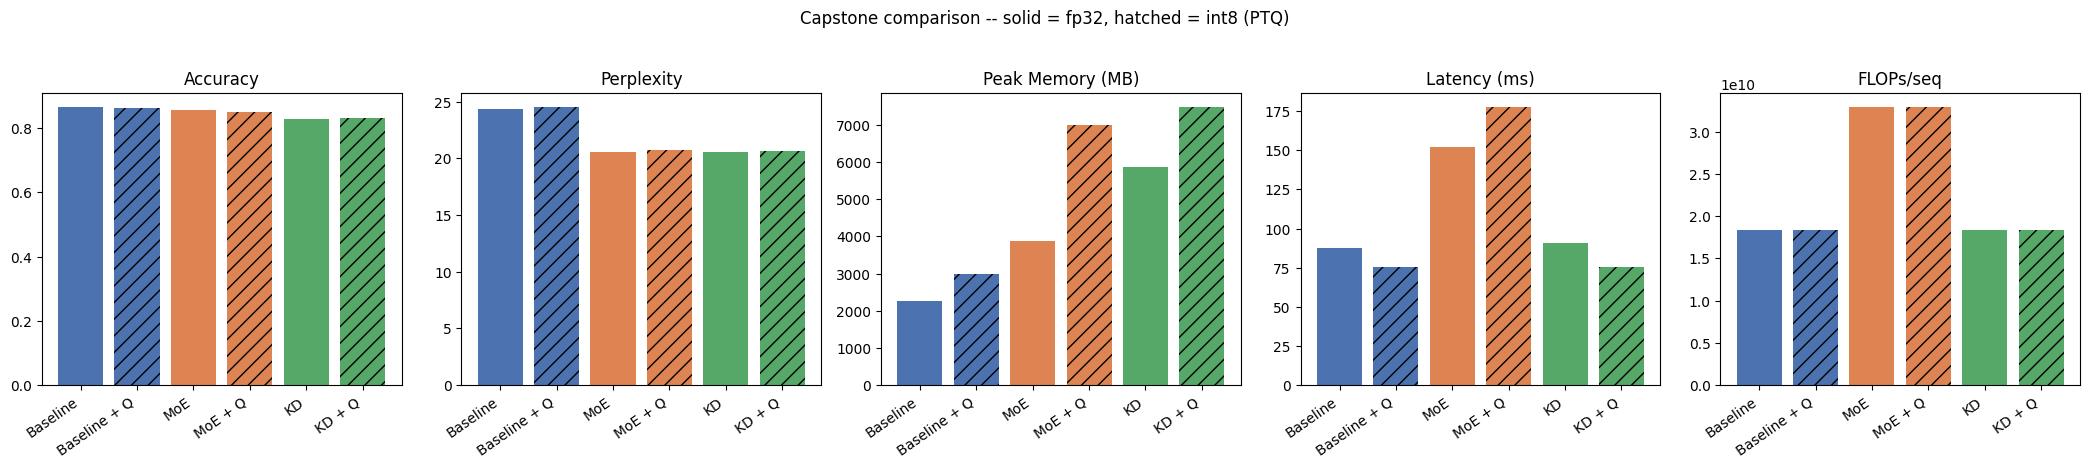

In [18]:
metrics_to_plot = ["Accuracy", "Perplexity", "Peak Memory (MB)", "Latency (ms)", "FLOPs/seq"]
group_colors = ["#4C72B0", "#4C72B0", "#DD8452", "#DD8452", "#55A868", "#55A868"]
hatches = ["", "//", "", "//", "", "//"]  # solid = fp32, hatched = int8

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4.2 * len(metrics_to_plot), 4.5))
for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(df.index, df[metric], color=group_colors)
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
    ax.set_title(metric)
    ax.set_xticklabels(df.index, rotation=35, ha="right")
plt.suptitle("Capstone comparison -- solid = fp32, hatched = int8 (PTQ)", y=1.03)
plt.tight_layout()
plt.savefig("ptq_capstone_plot.png", dpi=150)
plt.show()